In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from utils import (
    replace_infinite,
    min_max_norm,
    get_pareto_set,
    wlc_ranking,
    wd_ranking,
    hare_stv,
    get_tournament_matrix,
)

# Normalization of the criteria

In [ ]:
df = pd.read_csv("../decision_data_collection/models_metrics.csv")
df = df.drop("Unnamed: 0", axis=1)
df

,model,accuracy,precision,recall,f1,roc_auc,cv_mean,cv_std,train_time_sec,inference_time_sec,model_size_kb,latency,throughput,efficiency,stability,interpretability
0,DecisionTree_default,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.010000,0.002221,3.609375,1.366974e-06,7.315427e+05,0.277056,inf,5
1,RandomForest_small,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.167857,0.036894,219.852539,2.270417e-05,4.404477e+04,0.004549,inf,3
2,ExtraTrees_fast,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.134194,0.038403,278.919922,2.363263e-05,4.231437e+04,0.003585,inf,3
3,RandomForest_large,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.963290,0.175941,1325.002930,1.082717e-04,9.236025e+03,0.000755,inf,3
4,ExtraTrees_large,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.732264,0.155271,1701.605469,9.555149e-05,1.046556e+04,0.000588,inf,3
5,GradientBoosting_fast,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.263784,0.002043,69.969727,1.256933e-06,7.955874e+05,0.014292,inf,2
6,AdaBoost_heavy,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.951386,0.047423,163.905273,2.918344e-05,3.426600e+04,0.006101,inf,2
7,GradientBoosting_slow,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.048898,0.006169,261.228516,3.796463e-06,2.634030e+05,0.003828,inf,2
8,SVC_poly,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.750936,0.009415,45.899414,5.793700e-06,1.726013e+05,0.021787,inf,2
9,KNN_3,1.000000,1.000000,1.000000,1.000000,1.000000,0.999385,0.001231,0.002146,0.080911,1067.291992,4.979122e-05,2.008386e+04,0.000937,812.500000,1


In [3]:
# Replace inf with max finite value in column
df = replace_infinite(df)
# fill None values (roc-auc)
df = df.fillna(df.mean(numeric_only=True))

In [4]:
minimize_cols = [
    "cv_std",
    "train_time_sec",
    "inference_time_sec",
    "model_size_kb",
    "latency",
]

for col in minimize_cols:
    df[col] = df[col].max() - df[col]

In [5]:
df = min_max_norm(df)
df

,model,accuracy,precision,recall,f1,roc_auc,cv_mean,cv_std,train_time_sec,inference_time_sec,model_size_kb,latency,throughput,efficiency,stability,interpretability
0,DecisionTree_default,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.997802,0.993674,0.998599,0.993674,0.498963,0.350857,1.000000,1.00
1,RandomForest_small,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.953628,0.795346,0.871426,0.795346,0.024046,0.005027,1.000000,0.50
2,ExtraTrees_fast,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.963048,0.786716,0.836688,0.786716,0.022850,0.003804,1.000000,0.50
3,RandomForest_large,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.731037,0.000000,0.221482,0.000000,0.000000,0.000212,1.000000,0.50
4,ExtraTrees_large,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.795686,0.118234,0.000000,0.118234,0.000849,0.000000,1.000000,0.50
5,GradientBoosting_fast,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.926784,0.994697,0.959572,0.994697,0.543204,0.017392,1.000000,0.25
6,AdaBoost_heavy,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.734368,0.735121,0.904328,0.735121,0.017290,0.006997,1.000000,0.25
7,GradientBoosting_slow,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.707081,0.971092,0.847092,0.971092,0.175576,0.004112,1.000000,0.25
8,SVC_poly,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.790461,0.952528,0.973728,0.952528,0.112851,0.026903,1.000000,0.25
9,KNN_3,1.000000,1.000000,1.000000,1.000000,1.000000,0.993368,0.807904,1.000000,0.543573,0.373043,0.543573,0.007494,0.000443,0.560940,0.00


In [6]:
df.describe()

,accuracy,precision,recall,f1,roc_auc,cv_mean,cv_std,train_time_sec,inference_time_sec,model_size_kb,latency,throughput,efficiency,stability,interpretability
count,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000
mean,0.741975,0.647367,0.800089,0.748395,0.865559,0.748000,0.633409,0.875505,0.845180,0.841793,0.845180,0.384164,0.308399,0.512464,0.552083
std,0.347271,0.447951,0.304473,0.341518,0.287029,0.344485,0.375793,0.216800,0.270276,0.285817,0.270276,0.366179,0.383655,0.450804,0.329518
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.390741,0.049648,0.598404,0.413848,0.866928,0.429533,0.192184,0.794380,0.793188,0.865342,0.793188,0.023747,0.004798,0.031731,0.250000
50%,0.951852,1.000000,0.973404,0.953277,1.000000,0.955229,0.745391,0.961634,0.981033,0.978806,0.981033,0.292977,0.035173,0.424072,0.500000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.998461,0.997676,0.999623,0.997676,0.732133,0.641248,1.000000,0.750000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


# Pareto set

In [7]:
model_names = df.iloc[:, 0]   # first column = model name
pareto_set = get_pareto_set(df, model_names)

print(f"Size of original data: {len(df)}")
print(f"Size of Pareto set: {len(pareto_set)}")
pareto_set

Size of original data: 24
Size of Pareto set: 12


,model,accuracy,precision,recall,f1,roc_auc,cv_mean,cv_std,train_time_sec,inference_time_sec,model_size_kb,latency,throughput,efficiency,stability,interpretability
0,DecisionTree_default,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.997802,0.993674,0.998599,0.993674,0.498963,0.350857,1.000000,1.00
5,GradientBoosting_fast,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.926784,0.994697,0.959572,0.994697,0.543204,0.017392,1.000000,0.25
9,KNN_3,1.000000,1.000000,1.000000,1.000000,1.000000,0.993368,0.807904,1.000000,0.543573,0.373043,0.543573,0.007494,0.000443,0.560940,0.00
12,KNN_15,0.940741,1.000000,0.914894,0.942452,0.999658,0.930346,0.586729,0.999910,0.827220,0.373043,0.827220,0.029459,0.000437,0.189355,0.00
13,DecisionTree_shallow,0.925926,0.785076,1.000000,0.928887,0.997493,0.927027,0.682878,0.998949,0.999505,0.998691,0.999505,0.927566,0.364401,0.287204,1.00
14,DecisionTree_pruned,0.918519,0.891026,0.936170,0.921226,0.997937,0.930358,0.331129,0.998786,1.000000,0.998507,1.000000,1.000000,0.333986,0.066028,1.00
16,LogReg_weak_reg,0.614815,0.373560,0.755319,0.629272,0.900823,0.656716,0.607456,0.835129,0.996510,1.000000,0.996510,0.644182,1.000000,0.206396,1.00
17,LogReg_strong_reg,0.407407,0.051943,0.617021,0.430373,0.732511,0.459382,0.174601,0.960219,0.997506,0.999996,0.997506,0.717198,0.976743,0.028213,1.00
18,Ridge_alpha_small,0.340741,0.002545,0.542553,0.364271,1.000000,0.339984,0.192184,0.994233,0.990973,0.999982,0.990973,0.410379,0.952941,0.031731,0.75
19,LDA_svd,0.340741,0.002545,0.542553,0.364271,0.690046,0.339984,0.192184,0.995610,0.998336,0.999566,0.998336,0.791867,0.609765,0.031731,0.75


# Pareto graph

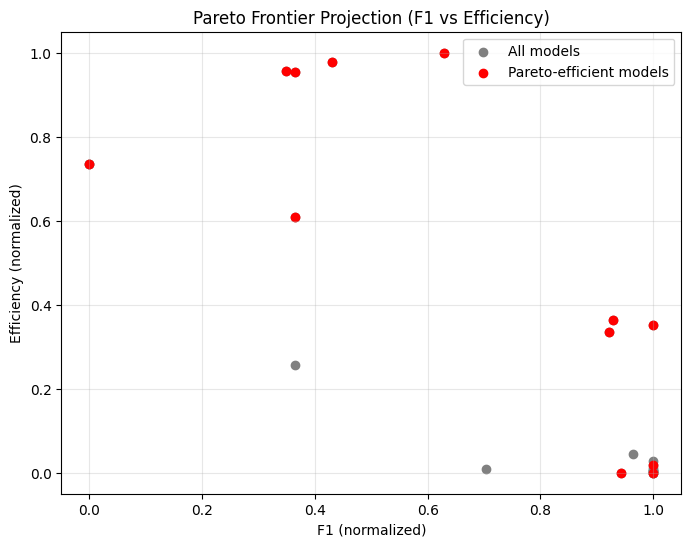

In [8]:
plt.figure(figsize=(8,6))

# All models
plt.scatter(
    df["f1"], 
    df["efficiency"], 
    color="gray", 
    label="All models"
)

# Pareto models
plt.scatter(
    pareto_set["f1"], 
    pareto_set["efficiency"], 
    color="red", 
    label="Pareto-efficient models"
)

plt.xlabel("F1 (normalized)")
plt.ylabel("Efficiency (normalized)")
plt.title("Pareto Frontier Projection (F1 vs Efficiency)")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

# Best alternative selection

## Weighted linear combination of criteria

In [9]:
weights = {
    "accuracy": 0.03,
    "precision": 0.05,
    "recall": 0.07,
    "f1": 0.15,
    "roc_auc": 0.10,
    "cv_mean": 0.02,
    "cv_std": 0.08,
    "train_time_sec": 0.03,
    "inference_time_sec": 0.08,
    "model_size_kb": 0.12,
    "latency": 0.06,
    "throughput": 0.05,
    "efficiency": 0.03,
    "stability": 0.05,
    "interpretability": 0.08
}

pareto_weighted_ranking = wlc_ranking(pareto_set, weights)
pareto_weighted_ranking

,model,WLC_score
0,DecisionTree_default,0.954354
13,DecisionTree_shallow,0.890697
5,GradientBoosting_fast,0.879892
14,DecisionTree_pruned,0.853819
16,LogReg_weak_reg,0.773293
9,KNN_3,0.663800
17,LogReg_strong_reg,0.654004
12,KNN_15,0.650671
21,Ridge_alpha_large,0.638895
18,Ridge_alpha_small,0.624398


In [10]:
weights_2 = {
    "accuracy": 0.02,
    "precision": 0.04,
    "recall": 0.05,
    "f1": 0.10,
    "roc_auc": 0.09,
    "cv_mean": 0.01,
    "cv_std": 0.06,
    "train_time_sec": 0.05,
    "inference_time_sec": 0.15,
    "model_size_kb": 0.10,
    "latency": 0.10,
    "throughput": 0.08,
    "efficiency": 0.07,
    "stability": 0.03,
    "interpretability": 0.05
}

pareto_weighted_ranking = wlc_ranking(pareto_set, weights_2)
pareto_weighted_ranking

,model,WLC_score
0,DecisionTree_default,0.912646
13,DecisionTree_shallow,0.890850
14,DecisionTree_pruned,0.867078
5,GradientBoosting_fast,0.848144
16,LogReg_weak_reg,0.820631
17,LogReg_strong_reg,0.739092
21,Ridge_alpha_large,0.738974
18,Ridge_alpha_small,0.710843
19,LDA_svd,0.691312
12,KNN_15,0.635454


## Weighted distance to the "ideal" point

In [11]:
pareto_weighted_distance = wd_ranking(pareto_set, weights)
pareto_weighted_distance

,model,distance_to_ideal
0,DecisionTree_default,0.158744
13,DecisionTree_shallow,0.221746
5,GradientBoosting_fast,0.291135
14,DecisionTree_pruned,0.307929
16,LogReg_weak_reg,0.321224
17,LogReg_strong_reg,0.482907
9,KNN_3,0.498150
12,KNN_15,0.506109
21,Ridge_alpha_large,0.509645
19,LDA_svd,0.516907


In [27]:
pareto_weighted_distance = wd_ranking(pareto_set, weights_2)
pareto_weighted_distance

,model,distance_to_ideal
0,DecisionTree_default,0.222690
13,DecisionTree_shallow,0.229112
16,LogReg_weak_reg,0.277661
14,DecisionTree_pruned,0.292479
5,GradientBoosting_fast,0.335921
17,LogReg_strong_reg,0.409688
21,Ridge_alpha_large,0.427299
19,LDA_svd,0.443737
18,Ridge_alpha_small,0.449575
12,KNN_15,0.522341


## Social choice ranking

### Scoring rules

In [25]:
pareto_set_criteria = pareto_set.loc[:, ~pareto_set.columns.isin(['model'])].rank(
    ascending=False,
    method="average"
)
pareto_set_criteria

,accuracy,precision,recall,f1,roc_auc,cv_mean,cv_std,train_time_sec,inference_time_sec,model_size_kb,latency,throughput,efficiency,stability,interpretability
0,2.0,2.5,2.5,2.0,3.0,1.5,1.5,7.0,9.0,8.0,9.0,9.0,8.0,1.5,3.0
5,2.0,2.5,2.5,2.0,3.0,1.5,1.5,11.0,8.0,10.0,8.0,8.0,10.0,1.5,10.0
9,2.0,2.5,2.5,2.0,3.0,3.0,3.0,1.0,12.0,11.5,12.0,12.0,11.0,3.0,11.5
12,4.0,2.5,6.0,4.0,6.0,5.0,6.0,2.0,11.0,11.5,11.0,11.0,12.0,6.0,11.5
13,5.0,6.0,2.5,5.0,8.0,6.0,4.0,4.0,2.0,7.0,2.0,2.0,7.0,4.0,3.0
14,6.0,5.0,5.0,6.0,7.0,4.0,7.0,5.0,1.0,9.0,1.0,1.0,9.0,7.0,3.0
16,7.0,7.0,7.0,7.0,9.0,7.0,5.0,12.0,7.0,1.0,7.0,7.0,1.0,5.0,3.0
17,8.0,8.0,8.0,8.0,10.0,8.0,11.0,10.0,6.0,2.0,6.0,6.0,2.0,11.0,3.0
18,9.5,10.5,9.5,9.5,3.0,9.5,8.5,9.0,10.0,4.0,10.0,10.0,4.0,8.5,7.5
19,9.5,10.5,9.5,9.5,11.0,9.5,8.5,8.0,4.0,6.0,4.0,4.0,6.0,8.5,7.5


In [26]:
n_models = len(model_names)

borda_scores = (n_models - pareto_set_criteria).sum(axis=1)

pareto_scoring_rules = pd.DataFrame(pareto_set["model"].copy())
pareto_scoring_rules["borda_score"] = borda_scores
pareto_scoring_rules = pareto_scoring_rules.sort_values("borda_score", ascending=False)
pareto_scoring_rules

,model,borda_score
13,DecisionTree_shallow,292.5
0,DecisionTree_default,290.5
14,DecisionTree_pruned,284.0
5,GradientBoosting_fast,278.5
16,LogReg_weak_reg,268.0
9,KNN_3,268.0
17,LogReg_strong_reg,253.0
12,KNN_15,250.5
21,Ridge_alpha_large,246.5
19,LDA_svd,244.0


### Rules based on majority relations

**Approval Voting**

In [44]:
threshold = 0.7  # approve if metric >= 0.7
pareto_set_criteria = pareto_set.loc[:, ~pareto_set.columns.isin(['model'])]
approval_matrix = (pareto_set_criteria >= threshold).astype(int)

# sum approvals across metrics
approval_scores = approval_matrix.sum(axis=1)

# attach model names and sort
df_approval = pd.DataFrame({
    "model": pareto_set["model"],
    "approval_score": approval_scores
}).sort_values("approval_score", ascending=False)

df_approval

,model,approval_score
0,DecisionTree_default,13
5,GradientBoosting_fast,12
14,DecisionTree_pruned,12
13,DecisionTree_shallow,12
12,KNN_15,9
9,KNN_3,8
16,LogReg_weak_reg,8
17,LogReg_strong_reg,8
21,Ridge_alpha_large,8
18,Ridge_alpha_small,7


**Hare’s Procedure** (Single Transferable Vote / STV)

In [18]:
ranked_preferences = pareto_set.loc[:, ~pareto_set.columns.isin(['model'])].rank(
    ascending=False,
    method="average"
)
models = pareto_set["model"].tolist()
ranked_preferences.index = models

In [19]:
winner_hare = hare_stv(ranked_preferences)
print("\nHare/STV winner:", winner_hare)

Round 1: eliminating KNN_3 with 1 votes
Round 2: eliminating KNN_15 with 1 votes
Round 3: eliminating GaussianNB_smoothed with 1 votes
Round 4: eliminating DecisionTree_shallow with 1 votes
Round 5: eliminating LogReg_weak_reg with 2 votes
Round 6: eliminating LogReg_strong_reg with 2 votes
Round 7: eliminating Ridge_alpha_large with 2 votes
Round 8: eliminating Ridge_alpha_small with 2 votes
Round 9: eliminating LDA_svd with 2 votes
Round 10: eliminating DecisionTree_pruned with 4 votes
Round 11: eliminating GradientBoosting_fast with 3 votes

Hare/STV winner: DecisionTree_default


### Rules based on the tournament matrix

In [22]:
tournament_matrix = get_tournament_matrix(pareto_set, models)
tournament_matrix

,DecisionTree_default,GradientBoosting_fast,KNN_3,KNN_15,DecisionTree_shallow,DecisionTree_pruned,LogReg_weak_reg,LogReg_strong_reg,Ridge_alpha_small,LDA_svd,Ridge_alpha_large,GaussianNB_smoothed
DecisionTree_default,0,1,1,1,1,1,1,1,1,1,1,1
GradientBoosting_fast,-1,0,1,1,0,1,1,1,1,1,0,1
KNN_3,-1,-1,0,1,1,1,1,1,1,1,1,1
KNN_15,-1,-1,-1,0,-1,-1,-1,1,1,1,1,1
DecisionTree_shallow,-1,0,-1,1,0,1,1,1,1,1,1,1
DecisionTree_pruned,-1,-1,-1,1,-1,0,1,1,1,1,1,1
LogReg_weak_reg,-1,-1,-1,1,-1,-1,0,1,1,1,1,1
LogReg_strong_reg,-1,-1,-1,-1,-1,-1,-1,0,1,1,1,1
Ridge_alpha_small,-1,-1,-1,-1,-1,-1,-1,-1,0,-1,1,1
LDA_svd,-1,-1,-1,-1,-1,-1,-1,-1,1,0,1,0


**Copeland score**

In [23]:
copeland_scores = (tournament_matrix == 1).sum(axis=1) - (tournament_matrix == -1).sum(axis=1)
pareto_copeland = pd.DataFrame({"copeland_score": copeland_scores})
pareto_copeland = pareto_copeland.sort_values("copeland_score", ascending=False)
pareto_copeland

,copeland_score
DecisionTree_default,11
GradientBoosting_fast,7
KNN_3,7
DecisionTree_shallow,6
DecisionTree_pruned,3
LogReg_weak_reg,1
KNN_15,-1
LogReg_strong_reg,-3
LDA_svd,-6
Ridge_alpha_small,-7
